<a href="https://colab.research.google.com/github/sandralungahi/Data-and-AI-mini-projects/blob/classification_models/Classification_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME: SANDRA LUNG'AHI

CYBER SHUJAA ID: CS-DA02-25069

TASK: CLASSIFICATION MODELS

DESCRIPTION: Using the Wine dataset from scikit-learn, I will explore and visualize the data, and train six models: Logistic Regression, Decision Tree, Random Forest, k-Nearest Neighbors, Naive Bayes and, Support Vector Machine.

In [1]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( classification_report, accuracy_score, confusion_matrix )

#Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

**1. Loading and exploration of the dataset**

In [2]:
# Load Dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

# Explore the dataset
print("Dataset shape:", X.shape)
print("\nClass labels:", wine.target_names)
print("\nFirst 5 rows of data:")
display(X.head())
display(X.describe())


# Check for missing values
print("\nMissing values per column:")
print(X.isnull().sum())


Dataset shape: (178, 13)

Class labels: ['class_0' 'class_1' 'class_2']

First 5 rows of data:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


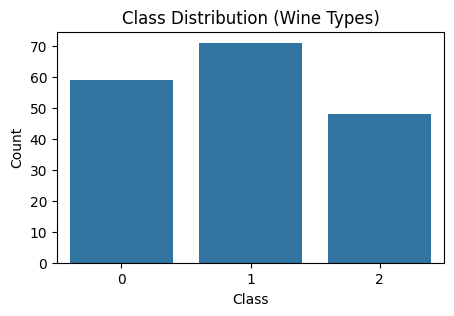

In [3]:
# Countplot for wine types
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title("Class Distribution (Wine Types)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

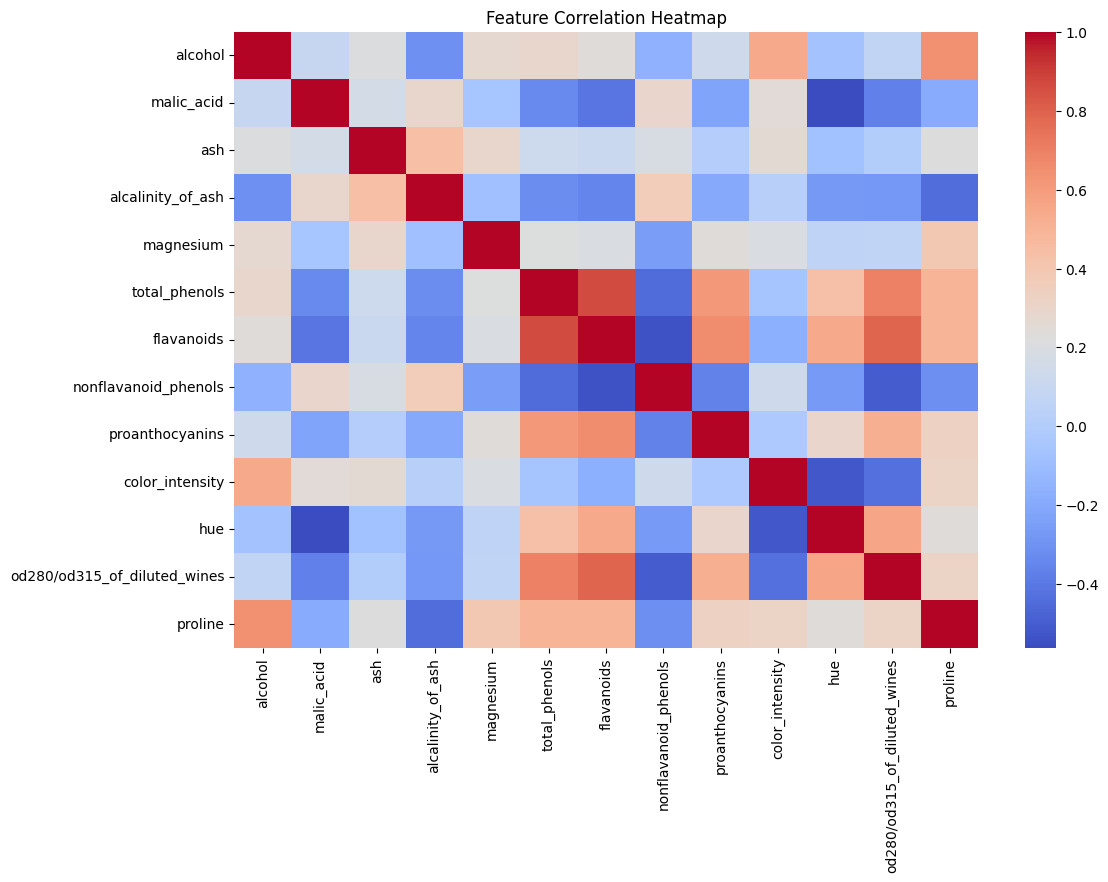

In [4]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

**2. Data Preparation**

In [5]:
# Prepare data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [8]:
# Confusion matrix plotting helper function
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=wine.target_names, yticklabels=wine.target_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()

**3. Train and evaluate the models**

 Logistic Regression

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



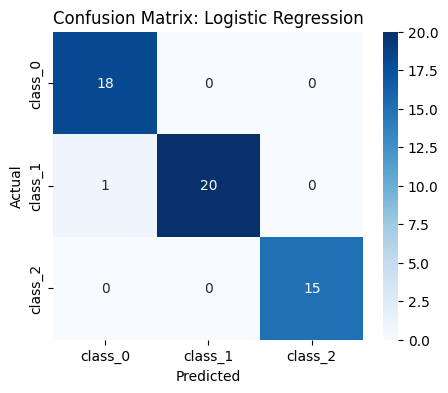

 Decision Tree

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.91      1.00      0.95        21
           2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



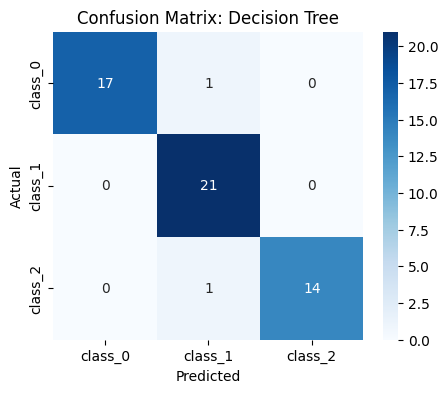

 Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



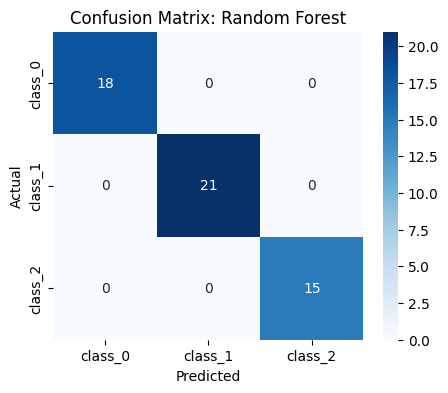

 K-Nearest Neighbors (KNN)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.86      0.92        21
           2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54



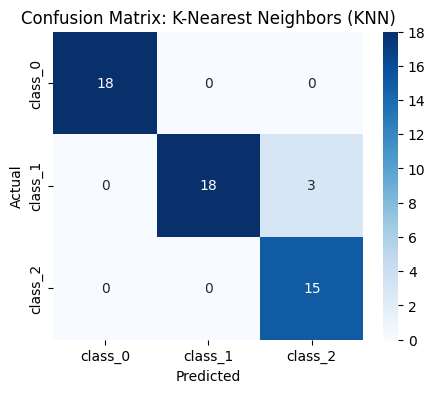

 Naive Bayes

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



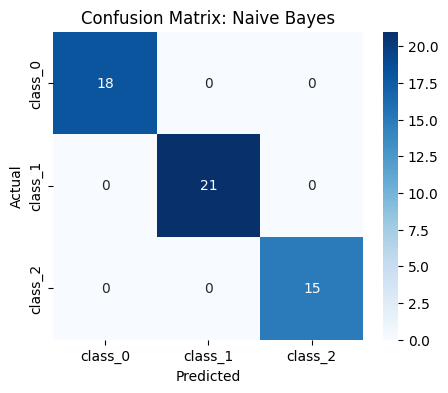

 Support Vector Machine (SVM)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



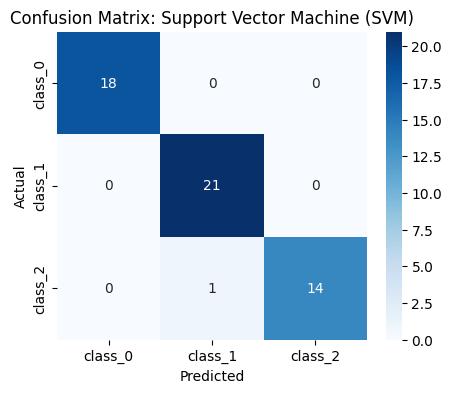

In [9]:
results = pd.DataFrame(columns=['Model', 'Accuracy'])

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(" Logistic Regression\n")
print(classification_report(y_test, y_pred_lr))
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")
results.loc[len(results)] = ['Logistic Regression', accuracy_score(y_test, y_pred_lr)]

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(" Decision Tree\n")
print(classification_report(y_test, y_pred_dt))
plot_conf_matrix(y_test, y_pred_dt, "Decision Tree")
results.loc[len(results)] = ['Decision Tree', accuracy_score(y_test, y_pred_dt)]

# 3. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(" Random Forest\n")
print(classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")
results.loc[len(results)] = ['Random Forest', accuracy_score(y_test, y_pred_rf)]

# 4. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(" K-Nearest Neighbors (KNN)\n")
print(classification_report(y_test, y_pred_knn))
plot_conf_matrix(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")
results.loc[len(results)] = ['K-Nearest Neighbors', accuracy_score(y_test, y_pred_knn)]

# 5. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print(" Naive Bayes\n")
print(classification_report(y_test, y_pred_nb))
plot_conf_matrix(y_test, y_pred_nb, "Naive Bayes")
results.loc[len(results)] = ['Naive Bayes', accuracy_score(y_test, y_pred_nb)]

# 6. Support Vector Machine (SVM)
svm = SVC(kernel='rbf', gamma='auto')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(" Support Vector Machine (SVM)\n")
print(classification_report(y_test, y_pred_svm))
plot_conf_matrix(y_test, y_pred_svm, "Support Vector Machine (SVM)")
results.loc[len(results)] = ['Support Vector Machine', accuracy_score(y_test, y_pred_svm)]

**4. Compare model performance**


 Model Comparison Results:



,Model,Accuracy
4,Naive Bayes,1.000000
2,Random Forest,1.000000
5,Support Vector Machine,0.981481
0,Logistic Regression,0.981481
1,Decision Tree,0.962963
3,K-Nearest Neighbors,0.944444


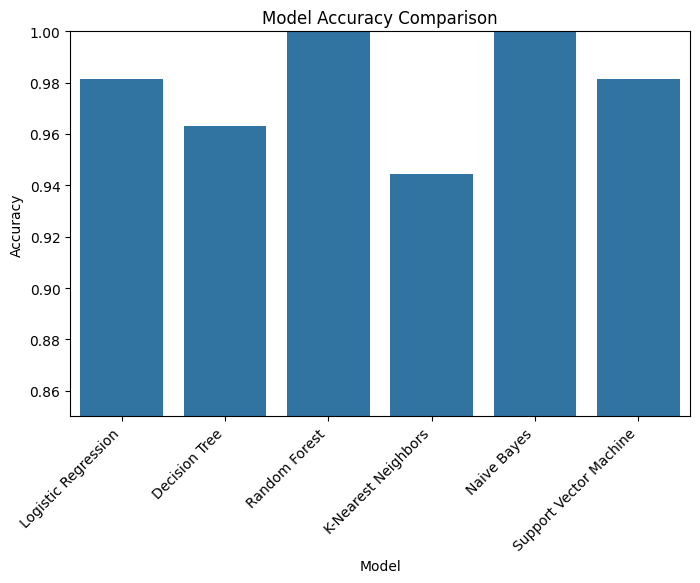


 Best Model: Random Forest with Accuracy = 1.000


In [10]:
print("\n Model Comparison Results:\n")
display(results.sort_values(by='Accuracy', ascending=False))

# Visualize comparison
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='Accuracy')
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.85, 1.0)
plt.show()

# Model performance interpretation
best_model = results.loc[results['Accuracy'].idxmax()]
print(f"\n Best Model: {best_model['Model']} with Accuracy = {best_model['Accuracy']:.3f}")